# <font color=#138D75> **B. Vibrational analysis** </font>
*Credit: heavily inspired by a notebook created by Magnus Ringholm, UiT The Arctic University of Norway*

In this exercise, we will see how we can determine and analyze the different vibrational motions that a molecule can have.

We will:

* Calculate the molecular Hessian of a small molecule and use it in a harmonic vibrational analysis to obtain the vibrational normal modes and their frequencies,
* Inspect animations of the normal mode motions to characterize them and predict IR/Raman activity,
* Use IR spectroscopy to carry out a bit of detective work in a task that brings together several concepts from the previous (optimization) and current section.

The main learning goals of this section are:

* Learn how to carry out a calculation of the mass-weighted molecular Hessian,
* Be able to carry out a harmonic vibrational analysis of a molecular system and understand the concept of a normal mode and determine the number of vibrational normal modes in a molecule,
* Learn to characterize different normal mode motions, understand the principal criterion for IR activity and judge whether a mode can be IR active,
* Use vibrational spectroscopy to carry out chemical analysis.

## <font color=#138D75> Execise 1 $-$ Harmonic vibrational analysis </font>

### <font color=#138D75> 1.1 Harmonic potential </font>

The potential energy surface can be expanded in a Taylor series around a configuration point $\mathbf{q}_a$. In the harmonic approximation, the Taylor expansion is truncated after the second-order term:
$$
V(\mathbf{q}) = E_a + \boldsymbol{\Delta}^\mathrm{T}_a\mathbf{g}_a + \frac12 \boldsymbol{\Delta}^\mathrm{T}_a \mathbf{H}_a \boldsymbol{\Delta}_a
$$
where $\boldsymbol{\Delta}_a=\mathbf{q}-\mathbf{q}_a$, $E_a$ is the energy at point  $\mathbf{q}_a$, $\mathbf{g}_a$ is the gradient, and $\mathbf{H}_a$ is the Hessian.

Around a minimum, the gradient is zero, so the change in energy by, e.g., a bond stretch from $b_0$ to $b$ can be approximated as:
$$
\Delta E = \frac{k}{2} (b - b_0)^2
$$
where $k$ is a force constant which depends on the curvature of the potential energy curve.

#### <font color="darkred"> **Tasks** </font> 
- Using the optimized geometry of the ethane molecule calculated in the previous exercise, stretch the C-C bond and obtain the 1D potential energy curve (PEC)
- Using points in the vicinity of the minimum-energy configuration, fit a quadratic (harmonic) potential to the PEC. Try the fit using:
  - the full energy curve,
  - an interval symmetric around the minimum in terms of distance,
  - an interval symmetric around the minimum in terms of energy. 

In [ ]:
import veloxchem as vlx
import geometric
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

np.set_printoptions(suppress=True, precision=5)

In [ ]:
def get_internal_coordinates(z_matrix):
    """ Creates a list of internal coordinates, based on the z_matrix.

        :param z_matrix: a list of atomic indices which define bonds, angles, and dihedrals.
    """
    internal_coordinates = []
    for z in z_matrix:
        # a bond is defined by 2 atoms
        if len(z) == 2:
            # indexing in geometric starts at 0
            q = geometric.internal.Distance(z[0]-1, z[1]-1)
            internal_coordinates.append(q)
        
        # an bond angle is defined by 3 atoms
        elif len(z) == 3:
            q = geometric.internal.Angle(z[0]-1, z[1]-1, z[2]-1)
            internal_coordinates.append(q)
        
        # a dihedral is defined by 4 atoms
        elif len(z) == 4:
            q = geometric.internal.Dihedral(z[0]-1, z[1]-1, z[2]-1, z[3]-1)
            internal_coordinates.append(q)
        else:
            print("Unrecognized type of coordinate.")
    return internal_coordinates

def print_coordinates(molecule, internal_coordinates):
    """ Print the values of theinternal coordinates.

        :param molecule: the molecule.
        :param internal_coordinates: the list of internal coordinates (geomeTRIC objects)
    """
    for q in internal_coordinates:
        if isinstance(q, geometric.internal.Distance):
            # Calculate the bond length and transform from au to Angstroms
            print(q, "     :  %8.5f Å  " % ( q.value(molecule.get_coordinates_in_angstrom())))
        if isinstance(q, geometric.internal.Angle):
            # Calculate the bond angle and transform from radians to degrees
            print(q, "      :  %6.1f deg " % ( q.value(molecule.get_coordinates_in_angstrom())*180/np.pi ))
        if isinstance(q, geometric.internal.Dihedral):
            # Calculate the dihedral and transform from radians to degrees
            print(q, " :  %6.1f deg " % (q.value(molecule.get_coordinates_in_angstrom())*180/np.pi))

In [ ]:
opt_molecule = vlx.Molecule.read_xyz_file("optimized_ethane.xyz")
basis = vlx.MolecularBasis.read(opt_molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "pbe"
scf_drv.ri_coulomb = True

In [ ]:
opt_molecule.show(atom_indices=True)

In [ ]:
# 3*N-6 = 18 non-redundant internal coordinates
# The Z-matrix is a list of atomic indices which define a bond, angle, or dihedral.
#            bond [a, b]       angle [a, b, c],       dihedral [a, b, c, d]

# z-matrix from the other notebook here
z_matrix =  [ [1, 2], [3, 1], [3, 1, 2], [4, 1], [4, 1, 2], [4, 1, 2, 6], [5, 1], [5, 1, 2], [5, 1, 2, 6],
             [6, 2], [6, 2, 1], [6, 2, 1, 4], [7, 2], [7, 2, 1], [7, 2, 1, 4], [8, 2], [8, 2, 1], [8, 2, 1, 4] ]

# Sort such that bonds appear first, angles next and dihedrals last
z_matrix = sorted(z_matrix, key=len)

internal_coordinates = get_internal_coordinates(z_matrix)

print("List of %d non-redundant internal coordinates:\n" % (len(internal_coordinates)))
print(internal_coordinates)
print()

In [ ]:
# Save the original bond length (for the optimized molecule)
original_bond_length = internal_coordinates[0].value(opt_molecule.get_coordinates_in_angstrom())

In [ ]:
# Create an array of bond lengths
# FILL IN YOUR CODE HERE
# CHOOSE A SMALL INTERVAL AROUND THE ORIGINAL BOND LENGTH
bond_lengths = np.arange(???, ???, 0.02)

# Mute the ostream
scf_drv.ostream.mute()

energies = []
for length in bond_lengths:
    print(f"Computing {length:10.2f} Å...")
    opt_molecule.set_distance_in_angstroms(z_matrix[0], length)
    scf_results = scf_drv.compute(opt_molecule, basis)
    if scf_drv.is_converged:
        energies.append(scf_drv.get_scf_energy())
    else:
        print("WARNING: SCF did not converge!")
scf_drv.ostream.unmute()

# Set the bond length back to its original value
opt_molecule.set_distance_in_angstroms(z_matrix[0], original_bond_length)

In [ ]:
plt.figure(figsize=(6, 4))

min_en = np.min(energies)
rel_energies = (energies - min_en) * vlx.hartree_in_ev()

plt.plot(bond_lengths, rel_energies, "-o", color="navy")

plt.axvline(x=original_bond_length, color="gray", ls="--")
plt.axhline(y=0, color="gray", ls="--")
plt.axhline(y=0.5, color="darkred", ls="--")


plt.xlabel("C-C bond length (Å)")
plt.ylabel("E-E$_0$ (eV)")
plt.title("1D cut through the potential energy surface")
plt.show()

In [ ]:
def harmonic_potential(b, b0, k):
    return (k / 2.0) * (b - b0) ** 2

In [ ]:
help(scipy.optimize.curve_fit)

In [ ]:
# FILL IN THE MISSING CODE
#                                    function to fit    x-data        y-data          initial guess for b0 and k
full_fit = scipy.optimize.curve_fit(harmonic_potential, bond_lengths, rel_energies, [original_bond_length, 1000])
symm_bond = scipy.optimize.curve_fit(harmonic_potential, ???, ???, [original_bond_length, 1000])
symm_energy = scipy.optimize.curve_fit(harmonic_potential, ???, ???, [original_bond_length, 1000])

In [ ]:
plt.figure(figsize=(6, 4))

min_en = np.min(energies)
rel_energies = (energies - min_en) * vlx.hartree_in_ev()

full_y = harmonic_potential(bond_lengths, full_fit[0][0], full_fit[0][1])
symb_y = harmonic_potential(bond_lengths, symm_bond[0][0], symm_bond[0][1])
syme_y = harmonic_potential(bond_lengths, symm_energy[0][0], symm_energy[0][1])


plt.plot(bond_lengths, rel_energies, "-o", color="navy")
plt.plot(bond_lengths, full_y, "--", color="darkred", label="full")
plt.plot(bond_lengths, symb_y, "--", color="red", label="symmetric - bond")
plt.plot(bond_lengths, syme_y, "--", color="orange", label="symmetric - energy")

plt.axvline(x=original_bond_length, color="gray", ls="--")
plt.axhline(y=0, color="gray", ls="--")

plt.xlabel("C-C bond length (Å)")
plt.ylabel("E-E$_0$ (eV)")
plt.title("Harmonic potential fit")
plt.legend()
plt.show()

#### <font color="darkred"> **Questions** </font> 
- How does the harmonic potential reproduce the potential energy curve?
- What are the differences betwen the different types of fits?
- How large are the force constants obtained by your fit and what units are they in?

### <font color=#138D75> 1.2 The molecular Hessian and vibrational analysis </font>

You already encountered the Hessian in the exercise about geometry optimization, where it was used as a source of information in carrying out optimization with the Newton-Raphson method. But it can also be used to understand the vibrational structure of a molecule, and that's what we are going to do now!

#### <font color="darkred"> **Questions** </font> 

* What is the molecular Hessian? What does its matrix elements consist of?
* What does "harmonic approximation" mean in the context of vibrational analysis?
* Can we carry out harmonic vibrational analysis at *any* conceivable molecular geometry?
* What does the term "normal modes of vibration" of a molecule actually mean?

**Background:** A very nice derivation of the eigenvalue equation for vibrational motion and why the (mass-weighted) Hessian is the key to the normal modes of the molecule can be found [here](https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Advanced_Theoretical_Chemistry_(Simons)/03:_Characteristics_of_Energy_Surfaces/3.02:_Normal_Modes_of_Vibration). This document was also a crucial source for the lecture material.

In [ ]:
opt_molecule.show(atom_indices=True)

#### <font color="darkred"> **Questions** </font> 

* How many degrees of freedom are there for translational and rotational motion of ethane?
* How many vibrational normal modes do you expect the molecule to have?

Using the `ScfHessianDriver` of VeloxChem, compute the Hessian for this molecule. 

In [ ]:
print_coordinates(opt_molecule, internal_coordinates)

In [ ]:
# First, we need to run our SCF calculation at the optimized geometry
scf_results = scf_drv.compute(opt_molecule, basis)

In [ ]:
hessian_drv = vlx.ScfHessianDriver(scf_drv)

In [ ]:
hessian_drv.compute(opt_molecule, basis)

In [ ]:
hessian_drv.print_hessian(opt_molecule)

The Hessian we just calculated is not mass-weighted, but we need it to be mass-weighted in order for its eigenanalysis to give the normal modes and their frequencies as a result (as shown in the lecture and [background material](https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Advanced_Theoretical_Chemistry_(Simons)/03:_Characteristics_of_Energy_Surfaces/3.02:_Normal_Modes_of_Vibration))

The mass-weighted Hessian is
$$
H^\mathrm{MW}_{ij} = \frac{H^\mathrm{cart}_{ij}}{\sqrt{m_i m_j}} 
$$

where $H^\mathrm{cart}_{ij}$ is an element of the the (non-mass-weighted) Hessian that we just calculated and $m_i$, $m_j$ are atomic masses. 

#### <font color="darkred"> **Tasks** </font> 
- Determine the the mass-weighted Hessian.
- Diagonalize it and obtain its eigenvalues and eigenvectors.

In [ ]:
# Get the atomic masses and number of atoms 
masses = opt_molecule.get_masses()
natms = opt_molecule.number_of_atoms()

# Get the regular Hessian as a numpy array
hessian = hessian_drv.get_hessian()

# Initialize the mass-weighted Hessian
mw_hessian = np.zeros_like(hessian)

for i in range(natms):
    for j in range(natms):
        inv_sqrt_mimj = 1 / np.sqrt(masses[i] * masses[j])
        mw_hessian[3*i:3*i+3, 3*j:3*j+3] = hessian[3*i:3*i+3, 3*j:3*j+3] * inv_sqrt_mimj

In [ ]:
help(np.linalg.eigh)

In [ ]:
mw_eigvals, mw__eigvecs = np.linalg.eigh(mw_hessian)
print(mw_eigvals)

#### <font color="darkred"> **Question** </font>
- What is the relation between the above eigenvalues and the vibrational frequencies?

Using your answer to this question and the fact that the eigenvalues are given in atomic units of energy$^{2}$ ("energy squared"), complete the following code to obtain the vibrational frequencies in units of inverse centimeters.

In [ ]:
# a.u. to cm^-1 conversion factor
au_to_cm1 = 5140.487142827606

# FILL IN YOUR CODE HERE
freqs = ????

print("These are the Hessian eigenvalues in a.u.:\n\n", mw_eigvals)
print("\nThese are the vibrational frequencies in inverse centimeters:\n")
print(freqs)

When we inspect these vibrational frequencies, we find that all of them are nonzero (even though some of them are very small). 

#### <font color="darkred"> **Question** </font>
- Is this expected?

The reason for this is that the vibrational analysis we just did neglected to separate the purely vibrational motions from the translational and rotational motions. That means that our modes can involve a mixture of all of these three kinds of motion - that's a bit messy!

Luckily, there is a remedy for this: We can project out the translational and rotational degrees of freedom before we mass-weight and diagonalize the Hessian. The full explanation of this procedure is beyond the scope of this course, so we will make use of the vibrational modes provided through the `VibrationalAnalysis` driver of VeloxChem, where translation and rotation are projected out by `geomeTRIC`.

#### <font color="darkred"> **Task** </font>
- Perform a vibrational analysis in VeloxChem and compare your results to the eigenvalues and eigenvectors where translation and rotation have been projected out.

#### <font color="darkred"> **Question** </font>
- How do the frequencies obtained using your mass-weighted Hessian compare to the vibrational frequencies produced by the `VibrationalAnalysis` driver, where rotation and translation are projected out?

In [ ]:
vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_results = vib_drv.compute(opt_molecule, basis)

In [ ]:
print(vib_results["vib_frequencies"])

## <font color=#138D75> Execise 2 $-$ IR Spectroscopy </font>

We will now study the vibrational motions more closely using the results we calculated above and see if we can make any predictions about the spectroscopic activity associated with them. Before proceeding, please consider testing your knowledge:

#### <font color="darkred"> **Question** </font>
* What is the meaning of the eigenvectors we have just calculated? That is, what do they tell us?

In [ ]:
vib_drv.animate(vib_results, mode=2)

#### <font color="darkred"> **Tasks** </font>
- Cycle through the mode index and record the following data for each mode:
    - Frequency
    - Type of motion (Stretching? Bending? Torsion? Symmetric or antisymmetric? Which atoms are (mainly) involved?
    - Make a prediction: will the mode be active in IR or not?

Let us plot the calculated IR spectrum and compare to an experimentally measured spectrum of gas phase ethane.

#### <font color="darkred"> **Questions** </font>
* Were your predictions correct?
* What is the criterion for deciding whether a given vibrational transition will be infrared active (and if so, how active it will be)?

In [ ]:
vib_drv.plot(vib_results)

Let's compare the calculation to experimental data from https://webbook.nist.gov/cgi/cbook.cgi?ID=C74840&Type=IR-SPEC&Index=0.

In [ ]:
exp_ir = pd.read_csv("ethane_ir.cvs")

import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel('Wavenumber [cm$^{-1}$]')
ax.set_ylabel('IR Absorbance [x 100]')
ax.set_title("Measured IR Spectrum, NIST")
ax.plot(exp_ir.wavenumbers, exp_ir.absorbance, "-o", markersize=1.5, linewidth=1.5, color="black")
ax.set_xlim(0, 4000)
ax.set_ylim(0, 40)


legend_spectrum = mlines.Line2D([], [],
                                color='black',
                                linestyle='-',
                                marker='o',
                                markersize=3,
                                linewidth=2.5,
                                label="experiment")

ax.legend(handles=[legend_spectrum],
                   frameon=False,
                   borderaxespad=0.,
                   loc='center left',
                   bbox_to_anchor=(1.05, 0.5))

plt.show()

In [ ]:
mode = 10

if 0 < mode and mode <= len(vib_results['vib_frequencies']):

    print("Mode %2d: %.2f cm\u207b\u00b9, IR intensity: %.2f km/mol" % (mode, vib_results['vib_frequencies'][mode-1],
                                                                       vib_results['ir_intensities'][mode-1]))
    vib_drv.animate(vib_results, mode=mode)
else:
    print("\n\x1b[1;41;41m Mode %2d does not exist. Please select a mode in the interval (1, %2d)! \x1b\n" %
     (mode, len(vib_results['vib_frequencies'])))

In [ ]:
def dipole_moment_along_normal_mode(molecule, basis, scf_drv, vib_results, mode):
    """ Calculate the change of the dipole moment along a normal mode.

        :param molecule: the molecule.
        :param basis: the basis set.
        :param scf_drv: the SCF driver (HF or DFT).
        :param vib_results: the dictionary of vibrational analysis results.
        :param mode: the index of the normal mode.
    """
    natm = molecule.number_of_atoms()

    x_list = np.arange(-0.6, 0.61, 0.2)
    displacements = vib_results['normal_modes'][mode-1].reshape(natm, 3)

    # Driver to calculate the dipole moment
    prop = vlx.FirstOrderProperties()
    dipole_moments = []

    scf_drv.ostream.mute()

    # Calculate the dipole moment for different displacements
    for x in x_list:
        print("Calculating dipole moment, displacement %.2f%%" % x)
        coords = molecule.get_coordinates_in_angstrom()
        coords += x * displacements
        distorted_molecule = vlx.molecule.Molecule(molecule.get_labels(),
                                                   coords, units="angstrom")
        scf_results = scf_drv.compute(distorted_molecule, basis)
        prop.compute_scf_prop(distorted_molecule, basis, scf_results)
        dipole_moment = prop.get_property("dipole moment")
        dipole_moments.append(dipole_moment)

    dipole_moments = np.array(dipole_moments)
    
    return{
    'displacements': np.array(x_list),
    'dipole_moments_x': dipole_moments[:, 0],
    'dipole_moments_y': dipole_moments[:, 1],
    'dipole_moments_z': dipole_moments[:, 2],
    }

In [ ]:
dipmom_results = dipole_moment_along_normal_mode(opt_molecule,
                                          basis,
                                          scf_drv,
                                          vib_results,
                                          mode=mode)

In [ ]:
print("Mode %2d: %.2f cm, IR intensity: %.2f km/mol" % (mode, vib_results['vib_frequencies'][mode-1],
                                                        vib_results['ir_intensities'][mode-1]))
figure = plt.figure(figsize=(6, 4))
displacements = dipmom_results["displacements"]
dipmom_x = dipmom_results["dipole_moments_x"]
dipmom_y = dipmom_results["dipole_moments_y"]
dipmom_z = dipmom_results["dipole_moments_z"]

plt.plot(displacements, dipmom_x, "--o", label="x")
plt.plot(displacements, dipmom_y, "--o", label="y")
plt.plot(displacements, dipmom_z, "--o", label="z")
plt.axis(xmin=-0.65, xmax=0.65)
plt.axis(ymin=-0.25, ymax=0.25)
plt.xlabel("Displacement (%)")
plt.ylabel("Dipole moment (a.u.)")
plt.title(
    "Dipole Moment along the %.2f cm-1 mode" % vib_results['vib_frequencies'][mode-1]
)
plt.legend()
plt.show()

### <font color=#138D75> Execise 3 $-$ Bringing it all together: A real-life application  </font>

In this final part of the exercise, you will get the chance to apply what you have learned here and in the exercise about optimization. Given below are the experimental IR spectra for two samples of dichloroethane, **1,1-dichloro-ethane** and **1,2-dichloro-ethane**, but... <font color="darkred"> **Oh, no!** </font>... Someone forgot to label which configurations of is which!


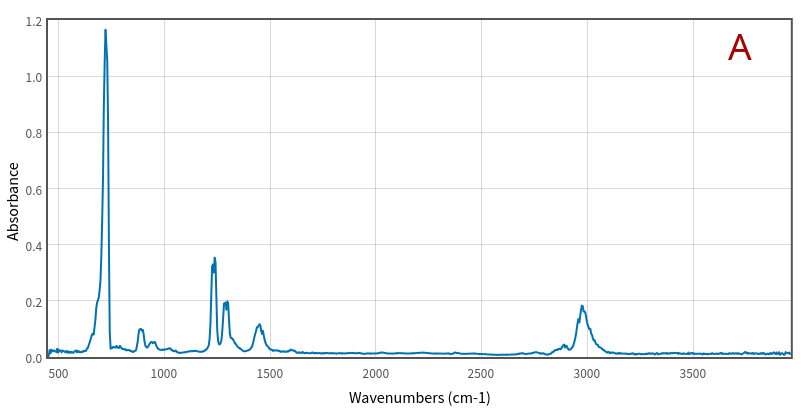

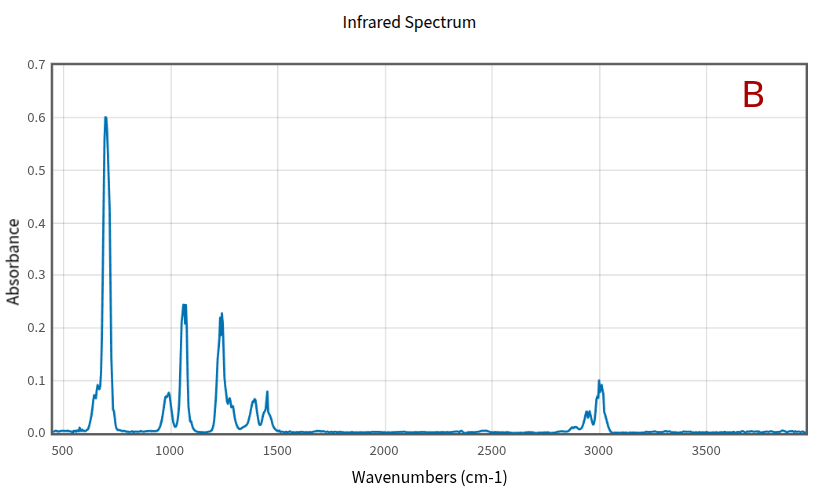

(Source: NIST)

#### <font color="darkred"> **Task** </font>
- Find out which isomer correspond to which spectrum by carrying out calculations!